# Day 4 — Gold: `care_gap_a1c`, prototyped

One row per diabetic patient. The product of the whole pipeline, sourced from
Silver only. Written here first, reviewed, then ported to `pipeline/gold.py`.

**Run order:** `load_bronze.py` → `corrupt.py` → `validate.py` → this notebook.

**DuckDB allows one process on the file at a time.** While this kernel holds `con`,
the `.py` scripts cannot open the database. Run the last cell (`con.close()`)
before running any `.py`, or shut the kernel down. Closing the tab does not stop it.

In [1]:
import duckdb
import pandas as pd
pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 50)

from cohort import DIABETES_CODES          # the eight SNOMED codes, Decision D5

DB   = "../data/warehouse/clinical.duckdb"
RAW  = "../data/raw/csv"
ASOF = "2026-08-23"                       # Decision D7
A1C  = "4548-4"
GAP_DAYS = 365
DX = ", ".join(f"'{c}'" for c in DIABETES_CODES)

con = duckdb.connect(DB)
def q(sql): return con.sql(sql).df()
print(len(DIABETES_CODES), "cohort codes |", "as of", ASOF)

8 cohort codes | as of 2026-08-23


## 4.1 — Lock both definitions (blocking)

**D5 — Diabetic patient.** Any of the eight SNOMED codes ever recorded on a patient
who is **alive on the as-of date**.

- *Ever recorded, not "unresolved":* 0 of 835 diabetes condition rows carry a stop
  date (Day 1), so "unresolved" and "ever" are the same set here. On real data,
  where type 2 diabetes is still managed rather than cured, I would keep "ever" and
  treat a resolved diabetes row as a data-quality question, not a cohort exit.
- *Alive on the as-of date:* a care-gap list is a call list. 45 of the 161 people
  carrying a diabetes code died before 2026-08-23. HEDIS excludes deceased members
  from the denominator; so do we.

**D6 — Open A1c gap.** No A1c result (LOINC `4548-4`, numeric value, observed on or
before the as-of date) in the 365 days before the as-of date. A patient who has
**never** been tested is a gap. Exactly 365 days is not a gap; 366 is.

- *Ordered but not resulted:* not observable here — Synthea has no orders table and
  no procedure row mentions A1c. On real data "we ordered it and the patient never
  went" and "we never ordered it" are different problems with different fixes, and
  a report counting only results conflates them. v1 conflates them and says so.
- *Results in another lab system:* also invisible. The number is "no result *we can
  see*", which is what every care-gap report actually measures.
- *Remediated values count:* the 20 A1cs corrected from 250 to 10.3 are results
  (Decision D4). A reviewer who disagrees excludes `_dq_status = 'remediated'`.

In [2]:
q(f"""
SELECT 'any of 8 codes ever recorded'            AS definition, count(DISTINCT c.patient_id) AS patients
FROM silver_conditions c WHERE c.snomed_code IN ({DX})
UNION ALL
SELECT '... and alive on {ASOF} (D5, the denominator)', count(DISTINCT c.patient_id)
FROM silver_conditions c JOIN silver_patients p USING (patient_id)
WHERE c.snomed_code IN ({DX}) AND (p.death_date IS NULL OR p.death_date > DATE '{ASOF}')
UNION ALL
SELECT '... deceased before as-of (excluded)', count(DISTINCT c.patient_id)
FROM silver_conditions c JOIN silver_patients p USING (patient_id)
WHERE c.snomed_code IN ({DX}) AND p.death_date <= DATE '{ASOF}'
""")

,definition,patients
0,any of 8 codes ever recorded,161
1,"... and alive on 2026-08-23 (D5, the denominator)",116
2,... deceased before as-of (excluded),45


## 4.2 — Build `care_gap_a1c`

Three CTEs: the cohort, each patient's latest A1c, each patient's active
medication count. Then **one LEFT JOIN** from cohort to latest A1c. That join
direction is the whole of task 4.3 — see the next section for what an inner
join would silently do.

In [3]:
con.sql(f"""
CREATE OR REPLACE TABLE care_gap_a1c AS
WITH cohort AS (                                       -- D5
    SELECT DISTINCT c.patient_id, p.birth_date
    FROM silver_conditions c
    JOIN silver_patients p USING (patient_id)
    WHERE c.snomed_code IN ({DX})
      AND (p.death_date IS NULL OR p.death_date > DATE '{ASOF}')
),
latest_a1c AS (                                        -- newest numeric result on or before as-of
    SELECT patient_id, observed_at::DATE AS last_a1c_date, value AS last_a1c_value
    FROM silver_observations
    WHERE loinc_code = '{A1C}' AND value IS NOT NULL AND observed_at <= TIMESTAMP '{ASOF}'
    QUALIFY row_number() OVER (PARTITION BY patient_id ORDER BY observed_at DESC) = 1
),
active_meds AS (                                       -- active on the as-of date
    SELECT patient_id, count(*) AS active_med_count
    FROM silver_medications
    WHERE start_date <= DATE '{ASOF}' AND (end_date IS NULL OR end_date > DATE '{ASOF}')
    GROUP BY patient_id
)
SELECT c.patient_id,
       date_part('year', age(DATE '{ASOF}', c.birth_date))::INT       AS age,
       a.last_a1c_date,
       a.last_a1c_value,
       date_diff('day', a.last_a1c_date, DATE '{ASOF}')                AS days_since_a1c,   -- NULL when never tested
       (a.last_a1c_date IS NULL OR date_diff('day', a.last_a1c_date, DATE '{ASOF}') > {GAP_DAYS}) AS gap_flag,
       coalesce(m.active_med_count, 0)                                 AS active_med_count,
       DATE '{ASOF}'                                                   AS asof_date
FROM cohort c
LEFT JOIN latest_a1c  a USING (patient_id)                            -- LEFT: never-tested patients must survive
LEFT JOIN active_meds m USING (patient_id)
""")
q("SELECT * FROM care_gap_a1c ORDER BY gap_flag DESC, days_since_a1c DESC NULLS FIRST LIMIT 8")

,patient_id,age,last_a1c_date,last_a1c_value,days_since_a1c,gap_flag,active_med_count,asof_date
0,6f7c5aea-661b-6b71-dd2b-26675910120b,61,NaT,NaN,<NA>,True,4,2026-08-23
1,e7932633-e86e-928c-8751-9d60d9b0c109,62,NaT,NaN,<NA>,True,4,2026-08-23
2,1e6d838f-8beb-a7f1-525e-5938ce602fb5,57,NaT,NaN,<NA>,True,2,2026-08-23
3,73321c11-174a-b0cd-27c7-d32c01773c1b,69,NaT,NaN,<NA>,True,4,2026-08-23
4,44f4479f-c075-5878-54fa-3919f72e7c59,59,NaT,NaN,<NA>,True,3,2026-08-23
5,e49fe9cd-e334-a3ea-2956-2d8eaa2bd64d,67,NaT,NaN,<NA>,True,5,2026-08-23
6,45902090-75ec-096d-13fa-dd1aece24f40,63,NaT,NaN,<NA>,True,5,2026-08-23
7,db0ecb2a-cd16-d4fd-0cfb-019ff298355b,60,NaT,NaN,<NA>,True,1,2026-08-23


In [4]:
q("""
SELECT count(*)                                         AS cohort,
       count(*) FILTER (WHERE gap_flag)                 AS open_gaps,
       round(100.0 * count(*) FILTER (WHERE gap_flag) / count(*), 1) AS gap_rate_pct,
       count(*) FILTER (WHERE last_a1c_date IS NULL)    AS never_tested,
       min(age) AS min_age, round(avg(age)) AS avg_age, max(age) AS max_age
FROM care_gap_a1c
""")

,cohort,open_gaps,gap_rate_pct,never_tested,min_age,avg_age,max_age
0,116,25,21.6,21,36,65.0,103


## 4.3 — The never-tested patient, and the inner-join bug

The highest-risk person on a care-gap list is the diabetic with no A1c on record.
An inner join from cohort to observations deletes exactly those people: the query
runs, the numbers look plausible, and the patients who most need a call are gone.
Here is the same build with the one word changed:

In [5]:
q(f"""
WITH cohort AS (
    SELECT DISTINCT c.patient_id FROM silver_conditions c JOIN silver_patients p USING (patient_id)
    WHERE c.snomed_code IN ({DX}) AND (p.death_date IS NULL OR p.death_date > DATE '{ASOF}')),
latest AS (
    SELECT patient_id, max(observed_at) AS last_a1c FROM silver_observations
    WHERE loinc_code = '{A1C}' AND value IS NOT NULL GROUP BY 1)
SELECT 'LEFT JOIN  (correct)' AS build, count(*) AS rows, count(*) FILTER (WHERE last_a1c IS NULL) AS never_tested_kept
FROM cohort LEFT JOIN latest USING (patient_id)
UNION ALL
SELECT 'INNER JOIN (the bug)', count(*), count(*) FILTER (WHERE last_a1c IS NULL)
FROM cohort JOIN latest USING (patient_id)
""")

,build,rows,never_tested_kept
0,LEFT JOIN (correct),116,21
1,INNER JOIN (the bug),95,0


The inner-join version reports fewer patients, zero of them never-tested, and
nothing errors. `days_since_a1c` is NULL for those patients — null arithmetic
propagates — which is why `gap_flag` tests `last_a1c_date IS NULL` explicitly
rather than relying on `NULL > 365`, which is *unknown*, not true.

## 4.4 — Hand-verify three patients, raw CSV to Gold row

One with a recent A1c (not flagged), one whose last A1c is over a year old
(flagged), one never tested (flagged, null date). Each traced from the raw
Synthea files, not from Silver — so the whole pipeline is checked, not just the
last step.

In [6]:
picks = q("""
(SELECT 'recent'  AS kind, patient_id FROM care_gap_a1c WHERE NOT gap_flag ORDER BY md5(patient_id) LIMIT 1)
UNION ALL
(SELECT 'stale',  patient_id FROM care_gap_a1c WHERE gap_flag AND last_a1c_date IS NOT NULL ORDER BY md5(patient_id) LIMIT 1)
UNION ALL
(SELECT 'never',  patient_id FROM care_gap_a1c WHERE last_a1c_date IS NULL ORDER BY md5(patient_id) LIMIT 1)
""")
for kind, pid in picks.itertuples(index=False):
    print(f"\n=== {kind.upper()}  {pid} ===")
    print("raw patients.csv   :", q(f"SELECT BIRTHDATE, DEATHDATE, FIRST, LAST FROM read_csv_auto('{RAW}/patients.csv', all_varchar=true) WHERE Id = '{pid}'").to_dict('records'))
    print("raw conditions.csv :", q(f"SELECT CODE, DESCRIPTION, START FROM read_csv_auto('{RAW}/conditions.csv', all_varchar=true) WHERE PATIENT = '{pid}' AND CODE IN ({DX}) ORDER BY START LIMIT 3").to_dict('records'))
    a1c = q(f"SELECT DATE, VALUE, UNITS FROM read_csv_auto('{RAW}/observations.csv', all_varchar=true) WHERE PATIENT = '{pid}' AND CODE = '{A1C}' ORDER BY DATE DESC LIMIT 3")
    print("raw observations.csv (A1c, newest first):", a1c.to_dict('records') if len(a1c) else "NONE - never tested")
    print("Gold row           :", q(f"SELECT age, last_a1c_date, last_a1c_value, days_since_a1c, gap_flag, active_med_count FROM care_gap_a1c WHERE patient_id = '{pid}'").to_dict('records'))


=== RECENT  c24941da-8187-d66c-bfc0-926199a69c9f ===


raw patients.csv   : [{'BIRTHDATE': '1977-05-03', 'DEATHDATE': None, 'FIRST': 'Augustine565', 'LAST': 'Nicolas769'}]
raw conditions.csv : [{'CODE': '44054006', 'DESCRIPTION': 'Diabetes mellitus type 2 (disorder)', 'START': '2008-07-15'}, {'CODE': '127013003', 'DESCRIPTION': 'Disorder of kidney due to diabetes mellitus (disorder)', 'START': '2016-11-01'}, {'CODE': '90781000119102', 'DESCRIPTION': 'Microalbuminuria due to type 2 diabetes mellitus (disorder)', 'START': '2022-12-13'}]


raw observations.csv (A1c, newest first): [{'DATE': '2026-06-16T07:41:50Z', 'VALUE': '4.5', 'UNITS': '%'}, {'DATE': '2026-04-14T07:41:50Z', 'VALUE': '4.5', 'UNITS': '%'}, {'DATE': '2026-03-17T07:41:50Z', 'VALUE': '4.5', 'UNITS': '%'}]
Gold row           : [{'age': 49, 'last_a1c_date': Timestamp('2026-06-16 00:00:00'), 'last_a1c_value': 4.5, 'days_since_a1c': 68, 'gap_flag': False, 'active_med_count': 5}]

=== STALE  df8d2de6-32a1-262d-b07f-1b73e77efef8 ===


raw patients.csv   : [{'BIRTHDATE': '1977-01-27', 'DEATHDATE': None, 'FIRST': 'Erin498', 'LAST': 'Collier206'}]
raw conditions.csv : [{'CODE': '44054006', 'DESCRIPTION': 'Diabetes mellitus type 2 (disorder)', 'START': '2011-04-14'}, {'CODE': '368581000119106', 'DESCRIPTION': 'Neuropathy due to type 2 diabetes mellitus (disorder)', 'START': '2017-02-02'}]


raw observations.csv (A1c, newest first): [{'DATE': '2025-02-20T08:40:36Z', 'VALUE': '7.0', 'UNITS': '%'}, {'DATE': '2024-01-18T08:40:36Z', 'VALUE': '7.0', 'UNITS': '%'}, {'DATE': '2023-02-16T08:40:36Z', 'VALUE': '7.0', 'UNITS': '%'}]
Gold row           : [{'age': 49, 'last_a1c_date': Timestamp('2025-02-20 00:00:00'), 'last_a1c_value': 7.0, 'days_since_a1c': 549, 'gap_flag': True, 'active_med_count': 3}]

=== NEVER  f52c7b09-9aa3-c2b6-2891-9422737ce2e2 ===


raw patients.csv   : [{'BIRTHDATE': '1962-12-26', 'DEATHDATE': None, 'FIRST': 'Samual455', 'LAST': 'Doyle959'}]
raw conditions.csv : [{'CODE': '127013003', 'DESCRIPTION': 'Disorder of kidney due to diabetes mellitus (disorder)', 'START': '2011-12-28'}, {'CODE': '90781000119102', 'DESCRIPTION': 'Microalbuminuria due to type 2 diabetes mellitus (disorder)', 'START': '2012-07-25'}, {'CODE': '157141000119108', 'DESCRIPTION': 'Proteinuria due to type 2 diabetes mellitus (disorder)', 'START': '2023-05-31'}]


raw observations.csv (A1c, newest first): NONE - never tested
Gold row           : [{'age': 63, 'last_a1c_date': NaT, 'last_a1c_value': nan, 'days_since_a1c': None, 'gap_flag': True, 'active_med_count': 6}]


## V4.x — validations

In [7]:
checks = {
 "V4.1 grain: rows == distinct patients":
    q("SELECT count(*) = count(DISTINCT patient_id) AS ok FROM care_gap_a1c").ok[0],
 "V4.2 never-tested survived, all flagged":
    q("SELECT count(*) > 0 AND bool_and(gap_flag) AS ok FROM care_gap_a1c WHERE last_a1c_date IS NULL").ok[0],
 "V4.3 days_since null-safe, non-negative, < 40000":
    q("SELECT count(*) = 0 AS ok FROM care_gap_a1c WHERE (last_a1c_date IS NULL AND days_since_a1c IS NOT NULL) OR days_since_a1c < 0 OR days_since_a1c > 40000").ok[0],
 "V4.4 gap_flag matches definition (>365)":
    q(f"SELECT bool_and(CASE WHEN gap_flag THEN days_since_a1c IS NULL OR days_since_a1c > {GAP_DAYS} ELSE days_since_a1c <= {GAP_DAYS} END) AS ok FROM care_gap_a1c").ok[0],
 "V4.5 cohort == written D5 definition":
    q(f"""SELECT (SELECT count(*) FROM care_gap_a1c) = (SELECT count(DISTINCT c.patient_id) FROM silver_conditions c JOIN silver_patients p USING (patient_id)
          WHERE c.snomed_code IN ({DX}) AND (p.death_date IS NULL OR p.death_date > DATE '{ASOF}')) AS ok""").ok[0],
 "V4.6 no quarantined patient in Gold":
    q("SELECT count(*) = 0 AS ok FROM care_gap_a1c g JOIN quarantine x ON x.source_row_id = g.patient_id AND x.source_table = 'bronze_patients'").ok[0],
 "V4.8 age plausible (0..120)":
    q("SELECT min(age) >= 0 AND max(age) <= 120 AS ok FROM care_gap_a1c").ok[0],
 "V4.9 gap rate believable (not 0%, not 100%)":
    q("SELECT avg(gap_flag::INT) BETWEEN 0.01 AND 0.99 AS ok FROM care_gap_a1c").ok[0],
}
for k, v in checks.items(): print(f"  {'ok ' if v else 'FAIL'}  {k}")
print("\nV4.4 boundary detail:")
display(q("SELECT gap_flag, count(*) n, min(days_since_a1c) min_days, max(days_since_a1c) max_days FROM care_gap_a1c GROUP BY 1 ORDER BY 1"))
print("V4.8 age distribution:")
display(q("SELECT (age // 10) * 10 AS decade, count(*) n, count(*) FILTER (WHERE gap_flag) gaps FROM care_gap_a1c GROUP BY 1 ORDER BY 1"))

  ok   V4.1 grain: rows == distinct patients
  ok   V4.2 never-tested survived, all flagged
  ok   V4.3 days_since null-safe, non-negative, < 40000
  ok   V4.4 gap_flag matches definition (>365)
  ok   V4.5 cohort == written D5 definition
  ok   V4.6 no quarantined patient in Gold
  ok   V4.8 age plausible (0..120)
  ok   V4.9 gap rate believable (not 0%, not 100%)

V4.4 boundary detail:


,gap_flag,n,min_days,max_days
0,False,91,3,357
1,True,25,540,2540


V4.8 age distribution:


,decade,n,gaps
0,30,2,1
1,40,10,2
2,50,26,6
3,60,43,10
4,70,22,5
5,80,5,1
6,90,6,0
7,100,2,0


## 4.x — What else can Gold answer?

Before adding a column, check the data can support it. Every question below was
tested against Silver for the 116-patient cohort; two were dropped because the
answer would be constant (`lost_to_followup` is 0 of 116 — Synthea patients never
disappear) or impossible (no phone or email in Synthea — address, city, ZIP only).

In [8]:
q(f"""
WITH cohort AS (SELECT patient_id FROM care_gap_a1c),
a1c AS (SELECT patient_id, observed_at, value FROM silver_observations
        WHERE loinc_code = '{A1C}' AND value IS NOT NULL AND patient_id IN (SELECT patient_id FROM cohort)),
per_pt AS (SELECT patient_id, count(*) n, arg_max(value, observed_at) last_v FROM a1c GROUP BY 1),
enc AS (SELECT patient_id, max(admission_ts)::DATE last_enc FROM silver_encounters WHERE patient_id IN (SELECT patient_id FROM cohort) GROUP BY 1),
meds AS (SELECT patient_id, rxnorm_code FROM silver_medications WHERE start_date <= DATE '{ASOF}' AND (end_date IS NULL OR end_date > DATE '{ASOF}'))
SELECT * FROM (VALUES
 ('TIMING',  'next_due_date / days_overdue',  (SELECT count(*) FROM per_pt), 'of 116 have a last A1c; the other 21 are due now'),
 ('TIMING',  'a1c_count_2y',                  (SELECT count(DISTINCT patient_id) FROM a1c WHERE observed_at >= TIMESTAMP '{ASOF}' - INTERVAL 730 DAY), 'of 116 have a result in the last 2 years'),
 ('TIMING',  'trend (needs >= 2 results)',    (SELECT count(*) FROM per_pt WHERE n >= 2), 'of 116 - feasible, but a detail-page join, not a Gold column'),
 ('TIMING',  'first_dx_date',                 (SELECT count(DISTINCT patient_id) FROM silver_conditions WHERE snomed_code IN ({DX}) AND patient_id IN (SELECT patient_id FROM cohort)), 'of 116'),
 ('VALUE',   'last_a1c_controlled (< 7.0)',   (SELECT count(*) FROM per_pt WHERE last_v >= 7.0), 'of 95 tested are >= 7.0 - the flag has signal'),
 ('CONTACT', 'last_encounter_date',           (SELECT count(*) FROM enc), 'of 116; 74 seen in the last 90 days'),
 ('CONTACT', 'lost_to_followup (> 730 d)',    (SELECT count(*) FROM enc WHERE date_diff('day', last_enc, DATE '{ASOF}') > 730), 'of 116 - DROPPED, always false here'),
 ('CONTACT', 'phone / email',                 0, 'DROPPED - not in Synthea'),
 ('SAFETY',  'identity_review_pending',       (SELECT count(*) FROM cohort WHERE patient_id IN (SELECT candidate_a_mrn FROM identity_review UNION SELECT candidate_b_mrn FROM identity_review)), 'of 116 - kept as a guard even though it is 0 here'),
 ('SAFETY',  'on_insulin',                    (SELECT count(DISTINCT patient_id) FROM meds WHERE rxnorm_code IN ('106892','311034') AND patient_id IN (SELECT patient_id FROM cohort)), 'of 116'),
 ('SAFETY',  'no diabetes medication',        (SELECT count(*) FROM cohort WHERE patient_id NOT IN (SELECT patient_id FROM meds WHERE rxnorm_code IN ('106892','311034','860975'))), 'of 116 on neither insulin nor metformin')
) t(family, question, found, note)
""")

,family,question,found,note
0,TIMING,next_due_date / days_overdue,95,of 116 have a last A1c; the other 21 are due now
1,TIMING,a1c_count_2y,93,of 116 have a result in the last 2 years
2,TIMING,trend (needs >= 2 results),92,"of 116 - feasible, but a detail-page join, not..."
3,TIMING,first_dx_date,116,of 116
4,VALUE,last_a1c_controlled (< 7.0),19,of 95 tested are >= 7.0 - the flag has signal
5,CONTACT,last_encounter_date,116,of 116; 74 seen in the last 90 days
6,CONTACT,lost_to_followup (> 730 d),0,"of 116 - DROPPED, always false here"
7,CONTACT,phone / email,0,DROPPED - not in Synthea
8,SAFETY,identity_review_pending,0,of 116 - kept as a guard even though it is 0 here
9,SAFETY,on_insulin,45,of 116


### The never-tested patients are the complication-only patients

Day 1 found 73 patients carrying a diabetic complication with no type 2 code.
Day 4 found 21 never-tested patients. Same people?

In [9]:
q("""
SELECT last_a1c_date IS NULL AS never_tested, count(*) AS patients,
       count(*) FILTER (WHERE patient_id IN (SELECT patient_id FROM silver_conditions WHERE snomed_code = '44054006')) AS has_t2dm_code,
       count(*) FILTER (WHERE patient_id NOT IN (SELECT patient_id FROM silver_conditions WHERE snomed_code = '44054006')) AS complication_only,
       count(*) FILTER (WHERE patient_id IN (SELECT patient_id FROM silver_medications WHERE rxnorm_code IN ('106892','311034') AND (end_date IS NULL OR end_date > asof_date))) AS on_insulin
FROM care_gap_a1c GROUP BY 1 ORDER BY 1 DESC
""")

,never_tested,patients,has_t2dm_code,complication_only,on_insulin
0,True,21,0,21,0
1,False,95,68,27,45


**All 21, exactly.** Not one never-tested patient carries `44054006`; every one carries
*Disorder of kidney due to diabetes mellitus*; none is on insulin. The patients a
single-code cohort misses, the patients an inner join deletes, and the patients
nobody is treating or testing are the same 21 people.

### When was the last A1c, and when is the next one needed?

In [10]:
q("""
SELECT patient_id[1:8]                                  AS patient,
       age,
       last_a1c_date                                    AS last_a1c,
       last_a1c_value                                   AS value,
       last_a1c_date + INTERVAL 365 DAY                 AS next_due,
       CASE WHEN last_a1c_date IS NULL
                THEN 'never tested - due now'
            WHEN gap_flag
                THEN 'overdue by ' || date_diff('day', last_a1c_date + INTERVAL 365 DAY, asof_date) || ' days'
            ELSE 'due in ' || date_diff('day', asof_date, last_a1c_date + INTERVAL 365 DAY) || ' days'
       END                                              AS status
FROM care_gap_a1c
ORDER BY gap_flag DESC, last_a1c_date NULLS FIRST
LIMIT 15
""")


,patient,age,last_a1c,value,next_due,status
0,6f7c5aea,61,NaT,NaN,NaT,never tested - due now
1,e7932633,62,NaT,NaN,NaT,never tested - due now
2,1e6d838f,57,NaT,NaN,NaT,never tested - due now
3,73321c11,69,NaT,NaN,NaT,never tested - due now
4,44f4479f,59,NaT,NaN,NaT,never tested - due now
5,e49fe9cd,67,NaT,NaN,NaT,never tested - due now
6,45902090,63,NaT,NaN,NaT,never tested - due now
7,db0ecb2a,60,NaT,NaN,NaT,never tested - due now
8,cb213d00,75,NaT,NaN,NaT,never tested - due now
9,c173b8ae,62,NaT,NaN,NaT,never tested - due now


In [11]:
q("""
SELECT CASE WHEN last_a1c_date IS NULL THEN '1  never tested - due now'
            WHEN gap_flag              THEN '2  overdue'
            WHEN date_diff('day', asof_date, last_a1c_date + INTERVAL 365 DAY) <= 30 THEN '3  due within 30 days'
            WHEN date_diff('day', asof_date, last_a1c_date + INTERVAL 365 DAY) <= 90 THEN '4  due within 90 days'
            ELSE '5  due later' END AS when_needed,
       count(*) AS patients
FROM care_gap_a1c
GROUP BY 1 ORDER BY 1
""")


,when_needed,patients
0,1 never tested - due now,21
1,2 overdue,4
2,3 due within 30 days,4
3,4 due within 90 days,8
4,5 due later,79


### Rebuild `care_gap_a1c` with nine more columns

Same three CTEs and the same LEFT JOIN, plus: `next_due_date`, `days_overdue`,
`a1c_count_2y`, `first_dx_date`, `last_a1c_controlled`, `last_encounter_date`,
`identity_review_pending`, `on_insulin`, and `priority` — a rank over the open gaps
only (NULL for everyone else), so the worklist sorts itself: never-tested first,
then most overdue, then highest last value, then insulin, then oldest.

In [12]:
con.sql(f"""
CREATE OR REPLACE TABLE care_gap_a1c AS
WITH cohort AS (
    SELECT DISTINCT c.patient_id, p.birth_date
    FROM silver_conditions c JOIN silver_patients p USING (patient_id)
    WHERE c.snomed_code IN ({DX}) AND (p.death_date IS NULL OR p.death_date > DATE '{ASOF}')
),
a1c AS (
    SELECT patient_id, observed_at, value
    FROM silver_observations
    WHERE loinc_code = '{A1C}' AND value IS NOT NULL AND observed_at <= TIMESTAMP '{ASOF}'
),
latest_a1c AS (
    SELECT patient_id, observed_at::DATE AS last_a1c_date, value AS last_a1c_value
    FROM a1c QUALIFY row_number() OVER (PARTITION BY patient_id ORDER BY observed_at DESC) = 1
),
a1c_2y AS (
    SELECT patient_id, count(*) AS a1c_count_2y FROM a1c
    WHERE observed_at >= TIMESTAMP '{ASOF}' - INTERVAL 730 DAY GROUP BY 1
),
first_dx AS (
    SELECT patient_id, min(onset_date) AS first_dx_date FROM silver_conditions
    WHERE snomed_code IN ({DX}) GROUP BY 1
),
last_enc AS (
    SELECT patient_id, max(admission_ts)::DATE AS last_encounter_date FROM silver_encounters
    WHERE admission_ts <= TIMESTAMP '{ASOF}' GROUP BY 1
),
active_meds AS (
    SELECT patient_id, count(*) AS active_med_count,
           bool_or(rxnorm_code IN ('106892', '311034')) AS on_insulin
    FROM silver_medications
    WHERE start_date <= DATE '{ASOF}' AND (end_date IS NULL OR end_date > DATE '{ASOF}')
    GROUP BY 1
),
under_review AS (
    SELECT candidate_a_mrn AS patient_id FROM identity_review WHERE status = 'pending'
    UNION SELECT candidate_b_mrn FROM identity_review WHERE status = 'pending'
),
base AS (
    SELECT c.patient_id,
           date_part('year', age(DATE '{ASOF}', c.birth_date))::INT AS age,
           a.last_a1c_date, a.last_a1c_value,
           date_diff('day', a.last_a1c_date, DATE '{ASOF}')          AS days_since_a1c,
           (a.last_a1c_date IS NULL OR date_diff('day', a.last_a1c_date, DATE '{ASOF}') > {GAP_DAYS}) AS gap_flag,
           coalesce(m.active_med_count, 0)                           AS active_med_count,
           DATE '{ASOF}'                                             AS asof_date,
           -- the nine
           a.last_a1c_date + INTERVAL {GAP_DAYS} DAY                 AS next_due_date,
           CASE WHEN date_diff('day', a.last_a1c_date, DATE '{ASOF}') > {GAP_DAYS}
                THEN date_diff('day', a.last_a1c_date, DATE '{ASOF}') - {GAP_DAYS} END AS days_overdue,
           coalesce(y.a1c_count_2y, 0)                               AS a1c_count_2y,
           f.first_dx_date,
           a.last_a1c_value < 7.0                                    AS last_a1c_controlled,   -- NULL when never tested
           e.last_encounter_date,
           c.patient_id IN (SELECT patient_id FROM under_review)     AS identity_review_pending,
           coalesce(m.on_insulin, false)                             AS on_insulin
    FROM cohort c
    LEFT JOIN latest_a1c  a USING (patient_id)      -- LEFT, never INNER
    LEFT JOIN a1c_2y      y USING (patient_id)
    LEFT JOIN first_dx    f USING (patient_id)
    LEFT JOIN last_enc    e USING (patient_id)
    LEFT JOIN active_meds m USING (patient_id)
)
SELECT *,
       CASE WHEN gap_flag THEN row_number() OVER (
            PARTITION BY gap_flag
            ORDER BY last_a1c_date IS NULL DESC, days_overdue DESC NULLS LAST,
                     last_a1c_value DESC NULLS LAST, on_insulin DESC, age DESC) END AS priority
FROM base
""")
q("SELECT column_name, data_type FROM information_schema.columns WHERE table_name = 'care_gap_a1c' ORDER BY ordinal_position")

,column_name,data_type
0,patient_id,VARCHAR
1,age,INTEGER
2,last_a1c_date,DATE
3,last_a1c_value,DOUBLE
4,days_since_a1c,BIGINT
5,gap_flag,BOOLEAN
6,active_med_count,BIGINT
7,asof_date,DATE
8,next_due_date,TIMESTAMP
9,days_overdue,BIGINT


### The worklist: who to call first

In [13]:
q("""
SELECT priority, patient_id[1:8] AS patient, age, last_a1c_date AS last_a1c, last_a1c_value AS value,
       next_due_date::DATE AS next_due, days_overdue, a1c_count_2y AS tests_2y,
       last_encounter_date AS last_seen, on_insulin, active_med_count AS meds, first_dx_date AS diagnosed
FROM care_gap_a1c WHERE gap_flag ORDER BY priority
""")

,priority,patient,age,last_a1c,value,next_due,days_overdue,tests_2y,last_seen,on_insulin,meds,diagnosed
0,1,dd31b260,85,NaT,NaN,NaT,<NA>,0,2026-05-23,False,4,2013-09-21
1,2,23018670,79,NaT,NaN,NaT,<NA>,0,2026-07-26,False,12,2016-07-17
2,3,cb213d00,75,NaT,NaN,NaT,<NA>,0,2026-05-18,False,11,2014-11-03
3,4,ff8b6ec6,75,NaT,NaN,NaT,<NA>,0,2026-07-05,False,6,2012-05-13
4,5,8670ef45,73,NaT,NaN,NaT,<NA>,0,2026-08-22,False,6,2025-04-12
5,6,73321c11,69,NaT,NaN,NaT,<NA>,0,2025-09-23,False,4,2001-05-08
6,7,e49fe9cd,67,NaT,NaN,NaT,<NA>,0,2026-03-25,False,5,2025-03-12
7,8,45902090,63,NaT,NaN,NaT,<NA>,0,2026-07-07,False,5,2022-09-26
8,9,f52c7b09,63,NaT,NaN,NaT,<NA>,0,2026-08-20,False,6,2011-12-28
9,10,c173b8ae,62,NaT,NaN,NaT,<NA>,0,2026-07-29,False,3,2021-06-16


In [14]:
q("""
SELECT count(*) AS cohort,
       count(*) FILTER (WHERE gap_flag) AS gaps,
       count(*) FILTER (WHERE last_a1c_date IS NULL) AS never_tested,
       count(*) FILTER (WHERE last_a1c_controlled = false) AS uncontrolled_last,
       count(*) FILTER (WHERE on_insulin) AS on_insulin,
       count(*) FILTER (WHERE identity_review_pending) AS under_review,
       count(*) FILTER (WHERE NOT gap_flag AND date_diff('day', asof_date, next_due_date) <= 90) AS due_within_90d
FROM care_gap_a1c
""")

,cohort,gaps,never_tested,uncontrolled_last,on_insulin,under_review,due_within_90d
0,116,25,21,19,45,0,12


In [15]:
q("""select * from care_gap_a1c""")

,patient_id,age,last_a1c_date,last_a1c_value,days_since_a1c,gap_flag,active_med_count,asof_date,next_due_date,days_overdue,a1c_count_2y,first_dx_date,last_a1c_controlled,last_encounter_date,identity_review_pending,on_insulin,priority
0,dd31b260-5ad0-2bff-3218-031136ec287c,85,NaT,NaN,<NA>,True,4,2026-08-23,NaT,<NA>,0,2013-09-21,<NA>,2026-05-23,False,False,1
1,23018670-880f-61c0-1ede-08c641bd8f84,79,NaT,NaN,<NA>,True,12,2026-08-23,NaT,<NA>,0,2016-07-17,<NA>,2026-07-26,False,False,2
2,cb213d00-b093-9237-bfa6-aff0aace6281,75,NaT,NaN,<NA>,True,11,2026-08-23,NaT,<NA>,0,2014-11-03,<NA>,2026-05-18,False,False,3
3,ff8b6ec6-50ab-03eb-66dc-50a6b96fb572,75,NaT,NaN,<NA>,True,6,2026-08-23,NaT,<NA>,0,2012-05-13,<NA>,2026-07-05,False,False,4
4,8670ef45-e53b-be2d-3cb7-2fb40a2343ce,73,NaT,NaN,<NA>,True,6,2026-08-23,NaT,<NA>,0,2025-04-12,<NA>,2026-08-22,False,False,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,95feb885-62f0-2deb-28ae-823b4cc4c612,41,2026-08-09,2.8,14,False,2,2026-08-23,2027-08-09,<NA>,10,2018-11-04,True,2026-08-09,False,True,<NA>
112,e35fd905-901e-248b-051d-2d9a37e8d704,79,2026-07-28,2.6,26,False,7,2026-08-23,2027-07-28,<NA>,4,2011-05-03,True,2026-07-28,False,True,<NA>
113,b18cdce2-6dbe-c7a5-6fb5-6517ae16bbcd,63,2026-06-29,2.5,55,False,8,2026-08-23,2027-06-29,<NA>,28,2004-09-06,True,2026-08-16,False,True,<NA>
114,c1dae8ce-e74b-bd46-0de4-7dee7c4ee666,76,2025-09-18,2.4,339,False,7,2026-08-23,2026-09-18,<NA>,2,1980-12-25,True,2026-05-21,False,True,<NA>


## 4.y — Six charts

Prototyped here, saved to `docs/img/` for the README and `FINDINGS.md`, then
rebuilt in Recharts for the app on Day 5.

Two rules being followed, both from the project's own findings:

- **Only what has shape gets a chart.** Catch rate (6 of 6), the reconciliation
  and the profile of the 21 stay as tables — six bars at 100% is worse than six
  rows of text.
- **Palette validated, not eyeballed.** Blue `#2a78d6` and orange `#eb6834` are
  slots 1 and 2 of a checked categorical palette. Red was the obvious choice for
  "deleted rows" and was rejected: against orange it scores ΔE 7.1, below the 15
  floor for normal vision. Every chart here uses at most two series.

In [16]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np, os, textwrap

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#dcdcd8", "#fcfcfb"
IMG = "../docs/img"; os.makedirs(IMG, exist_ok=True)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 10, "text.color": INK, "axes.labelcolor": MUTED, "axes.edgecolor": GRID,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "figure.dpi": 130, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def finish(ax, title, subtitle=None, wrap=86):
    """Title above subtitle, both left-aligned, neither overlapping the other."""
    if subtitle:
        s = textwrap.fill(subtitle, wrap)
        ax.text(0, 1.02, s, transform=ax.transAxes, fontsize=9.5, color=MUTED,
                va="bottom", linespacing=1.45)
        ax.text(0, 1.04 + 0.062 * (s.count("\n") + 1), title, transform=ax.transAxes,
                fontsize=13, fontweight="600", color=INK, va="bottom")
    else:
        ax.text(0, 1.03, title, transform=ax.transAxes, fontsize=13,
                fontweight="600", color=INK, va="bottom")

def save(fig, name):
    fig.savefig(f"{IMG}/{name}.png"); print(f"  -> docs/img/{name}.png")

print("palette validated: blue+orange PASS all six checks (light mode)")

palette validated: blue+orange PASS all six checks (light mode)


### 1 — Cohort funnel: every exclusion decision in one picture

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


  -> docs/img/01_cohort_funnel.png


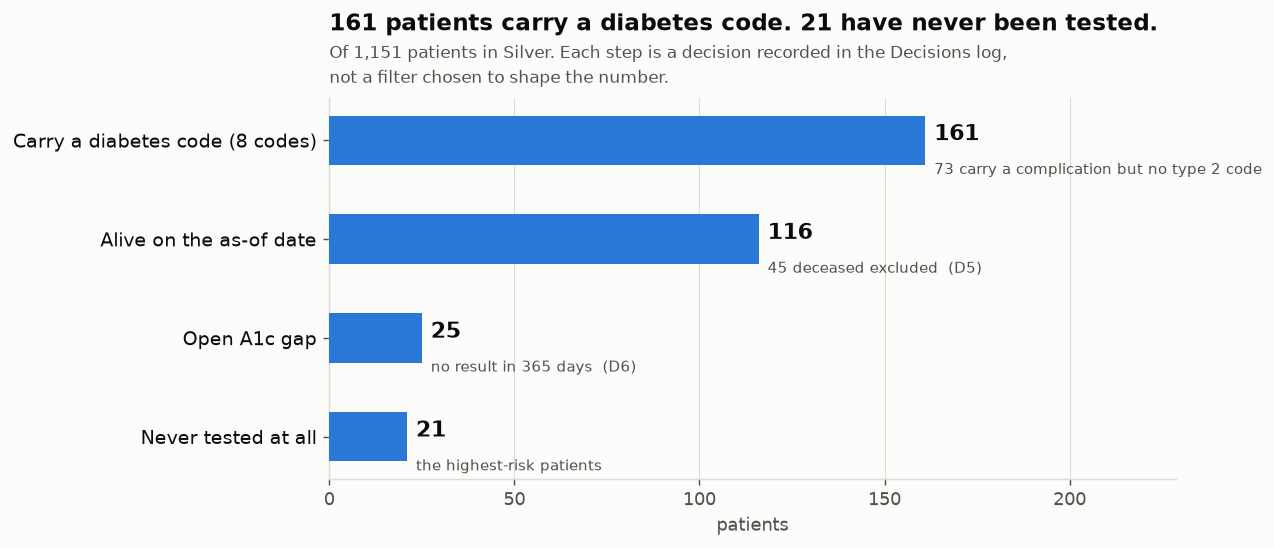

In [17]:
# The funnel starts at the cohort, not at every patient: 1,151 vs 21 is a 55:1 range
# that flattens the steps that matter. The full population is stated in the subtitle.
steps = q(f"""
SELECT 'Carry a diabetes code (8 codes)' AS step, (SELECT count(DISTINCT patient_id) FROM silver_conditions WHERE snomed_code IN ({DX})) AS n, 1 AS ord
UNION ALL SELECT 'Alive on the as-of date',  (SELECT count(*) FROM care_gap_a1c), 2
UNION ALL SELECT 'Open A1c gap',             (SELECT count(*) FROM care_gap_a1c WHERE gap_flag), 3
UNION ALL SELECT 'Never tested at all',      (SELECT count(*) FROM care_gap_a1c WHERE last_a1c_date IS NULL), 4
ORDER BY ord
""")
total = int(q("SELECT count(*) AS n FROM silver_patients").n[0])
notes = ["73 carry a complication but no type 2 code", "45 deceased excluded  (D5)",
         "no result in 365 days  (D6)", "the highest-risk patients"]

fig, ax = plt.subplots(figsize=(8.4, 3.8))
y = np.arange(len(steps))[::-1]
ax.barh(y, steps.n, height=0.5, color=BLUE, zorder=3)
for yi, (n, note) in zip(y, zip(steps.n, notes)):
    ax.text(n + steps.n.max() * 0.015, yi + 0.06, f"{n:,}", va="center", fontsize=12, fontweight="700", color=INK)
    ax.text(n + steps.n.max() * 0.015, yi - 0.30, note, va="center", fontsize=8.5, color=MUTED)
ax.set_yticks(y, steps.step, fontsize=10.5, color=INK)
ax.set_xlim(0, steps.n.max() * 1.42); ax.set_xlabel("patients")
ax.grid(axis="y", visible=False)
finish(ax, f"{steps.n.iloc[0]} patients carry a diabetes code. 21 have never been tested.",
       f"Of {total:,} patients in Silver. Each step is a decision recorded in the Decisions log, "
       "not a filter chosen to shape the number.")
save(fig, "01_cohort_funnel"); plt.show()

### 2 — The inner-join bug: what one word deletes

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


  -> docs/img/02_inner_join.png


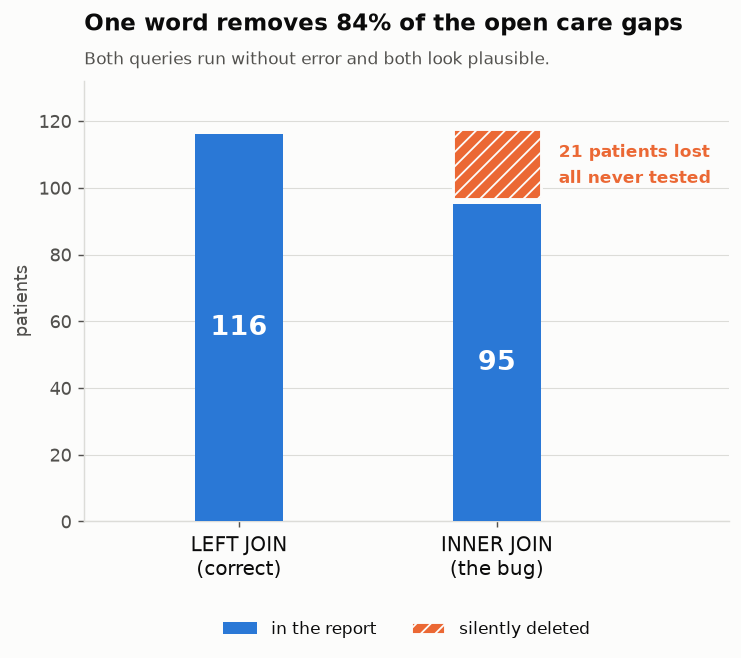

In [18]:
cmp = q(f"""
WITH cohort AS (SELECT patient_id FROM care_gap_a1c),
latest AS (SELECT patient_id FROM silver_observations
           WHERE loinc_code = '{A1C}' AND value IS NOT NULL AND observed_at <= TIMESTAMP '{ASOF}' GROUP BY 1)
SELECT 'LEFT JOIN\n(correct)' AS build, (SELECT count(*) FROM cohort c LEFT JOIN latest l USING (patient_id)) AS kept, 0 AS lost
UNION ALL
SELECT 'INNER JOIN\n(the bug)', (SELECT count(*) FROM cohort c JOIN latest l USING (patient_id)),
       (SELECT count(*) FROM cohort) - (SELECT count(*) FROM cohort c JOIN latest l USING (patient_id))
""")

fig, ax = plt.subplots(figsize=(6.4, 4.4))
x = np.arange(len(cmp))
ax.bar(x, cmp.kept, width=0.34, color=BLUE, label="in the report", zorder=3)
ax.bar(x, cmp.lost, width=0.34, bottom=cmp.kept + 1.5, color=ORANGE, label="silently deleted",
       hatch="///", edgecolor=SURFACE, linewidth=1.6, zorder=3)
for xi, (k, l) in enumerate(zip(cmp.kept, cmp.lost)):
    ax.text(xi, k / 2, f"{k}", ha="center", va="center", color="white", fontsize=15, fontweight="700")
    if l:
        ax.text(xi + 0.24, k + l / 2 + 1.5, f"{l} patients lost\nall never tested",
                ha="left", va="center", color=ORANGE, fontsize=9.5, fontweight="600", linespacing=1.4)
ax.set_xticks(x, cmp.build, fontsize=11, color=INK)
ax.set_xlim(-0.6, 1.9); ax.set_ylabel("patients"); ax.set_ylim(0, 132)
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.30), ncols=2, fontsize=9.5)
finish(ax, "One word removes 84% of the open care gaps",
       "Both queries run without error and both look plausible.")
save(fig, "02_inner_join"); plt.show()

### 3 — Last A1c per patient, against the 365-day line

  -> docs/img/03_last_a1c_timeline.png


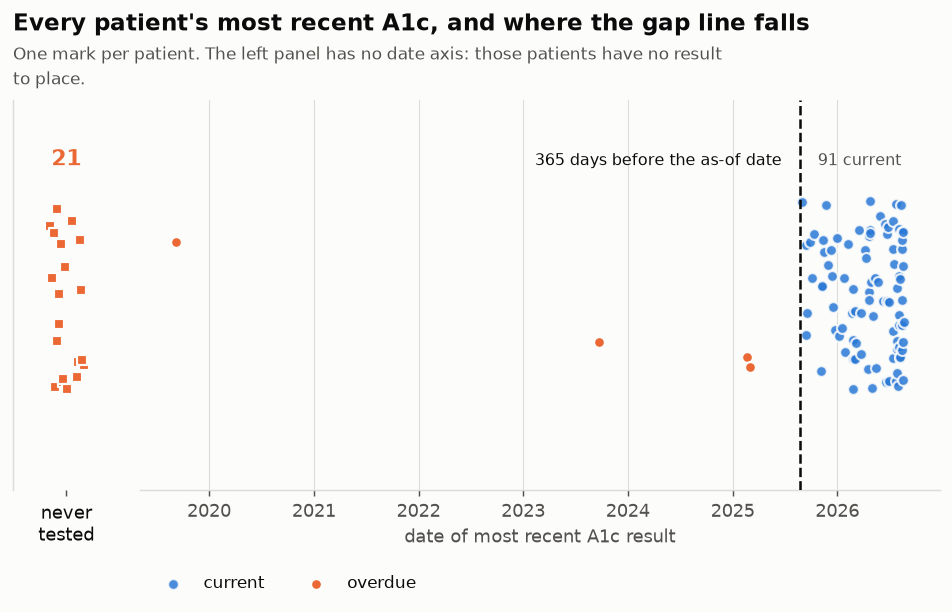

In [19]:
# Never-tested patients have NO date. Putting them on the date axis would read as
# "tested then", so they get their own panel with no shared x-scale.
pts = q("SELECT last_a1c_date, gap_flag FROM care_gap_a1c WHERE last_a1c_date IS NOT NULL ORDER BY last_a1c_date")
n_never = int(q("SELECT count(*) AS n FROM care_gap_a1c WHERE last_a1c_date IS NULL").n[0])
cutoff = np.datetime64(ASOF) - np.timedelta64(365, "D")
rng = np.random.default_rng(20260823)

fig, (axl, axr) = plt.subplots(1, 2, figsize=(9.2, 3.9), width_ratios=[1, 7.5],
                               gridspec_kw={"wspace": 0.045})

axl.scatter(rng.uniform(-.34, .34, n_never), rng.uniform(-.38, .38, n_never), s=36, color=ORANGE,
            marker="s", linewidths=1.2, edgecolors=SURFACE, zorder=3)
axl.set_xlim(-1, 1); axl.set_xticks([0], ["never\ntested"], color=INK)
axl.set_ylim(-.78, .78); axl.set_yticks([]); axl.grid(visible=False)
for s in ("top", "right", "bottom"): axl.spines[s].set_visible(False)
axl.text(0, .52, f"{n_never}", ha="center", fontsize=12, fontweight="700", color=ORANGE)

d = pts.last_a1c_date.values.astype("datetime64[D]")
jit = rng.uniform(-.38, .38, len(d)); ok, gap = ~pts.gap_flag.values, pts.gap_flag.values
axr.scatter(d[ok], jit[ok], s=36, color=BLUE, alpha=.85, linewidths=1.2, edgecolors=SURFACE, label="current", zorder=3)
axr.scatter(d[gap], jit[gap], s=36, color=ORANGE, linewidths=1.2, edgecolors=SURFACE, label="overdue", zorder=4)
axr.axvline(cutoff, color=INK, lw=1.4, ls="--", zorder=5)
axr.text(cutoff - np.timedelta64(28, "D"), .52, "365 days before the as-of date  ",
         fontsize=9, color=INK, ha="right")
axr.text(cutoff + np.timedelta64(28, "D"), .52, f"  {int(ok.sum())} current", fontsize=9, color=MUTED)
axr.set_ylim(-.78, .78); axr.set_yticks([]); axr.grid(axis="y", visible=False)
axr.set_xlabel("date of most recent A1c result")
axr.legend(frameon=False, loc="lower left", fontsize=9.5, ncols=2, bbox_to_anchor=(0, -0.30))
for s in ("top", "right", "left"): axr.spines[s].set_visible(False)

finish(axl, "Every patient's most recent A1c, and where the gap line falls",
       "One mark per patient. The left panel has no date axis: those patients have no result to place.")
save(fig, "03_last_a1c_timeline"); plt.show()

### 4 — A1c distribution and the floor the spec got wrong

  -> docs/img/04_a1c_floor.png


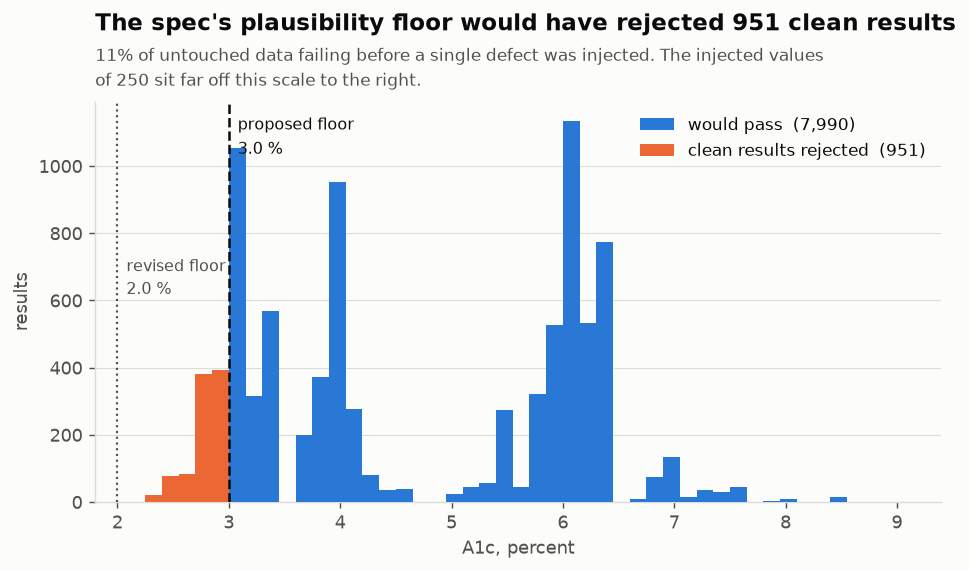

In [20]:
# The claim is about CLEAN data - "before a single defect was injected" - so this
# reads the raw CSV, not Silver. In Silver the count is 947, because 4 of the 20
# rows corrupt.py sets to 250 were originally below 3.0.
vals = q(f"""SELECT TRY_CAST(VALUE AS DOUBLE) AS v
             FROM read_csv_auto('{RAW}/observations.csv', all_varchar=true)
             WHERE CODE = '{A1C}' AND TRY_CAST(VALUE AS DOUBLE) IS NOT NULL""").v.values
below = int((vals < 3.0).sum())

fig, ax = plt.subplots(figsize=(8.4, 4.0))
bins = np.arange(1.8, 9.4, 0.15)
ax.hist(vals[vals >= 3.0], bins=bins, color=BLUE, zorder=3, label=f"would pass  ({len(vals)-below:,})")
ax.hist(vals[vals < 3.0], bins=bins, color=ORANGE, zorder=3, label=f"clean results rejected  ({below})")
top = ax.get_ylim()[1]
ax.axvline(3.0, color=INK, lw=1.4, ls="--", zorder=5)
ax.text(3.08, top * .97, "proposed floor\n3.0 %", fontsize=9, color=INK, va="top", linespacing=1.4)
ax.axvline(2.0, color=MUTED, lw=1.2, ls=":", zorder=5)
ax.text(2.08, top * .62, "revised floor\n2.0 %", fontsize=9, color=MUTED, va="top", linespacing=1.4)
ax.set_xlabel("A1c, percent"); ax.set_ylabel("results"); ax.set_xlim(1.8, 9.4)
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="upper right", fontsize=9.5)
finish(ax, f"The spec's plausibility floor would have rejected {below} clean results",
       f"{below/len(vals):.0%} of untouched data failing before a single defect was injected. "
       "The injected values of 250 sit far off this scale to the right.")
save(fig, "04_a1c_floor"); plt.show()

### 5 — Gap rate by age decade

  -> docs/img/05_gap_by_age.png


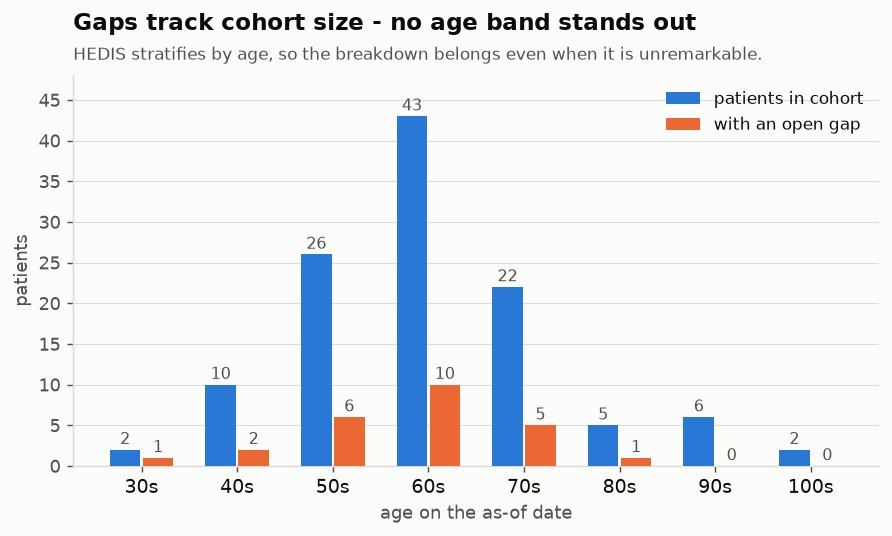

In [21]:
dec = q("SELECT (age // 10) * 10 AS decade, count(*) AS patients, count(*) FILTER (WHERE gap_flag) AS gaps FROM care_gap_a1c GROUP BY 1 ORDER BY 1")
fig, ax = plt.subplots(figsize=(8.0, 3.9))
x = np.arange(len(dec)); w = 0.32
ax.bar(x - w/2 - 0.012, dec.patients, w, color=BLUE, label="patients in cohort", zorder=3)
ax.bar(x + w/2 + 0.012, dec.gaps, w, color=ORANGE, label="with an open gap", zorder=3)
for xi, (p, g) in enumerate(zip(dec.patients, dec.gaps)):
    ax.text(xi - w/2 - 0.012, p + 0.7, str(p), ha="center", fontsize=9, color=MUTED)
    ax.text(xi + w/2 + 0.012, g + 0.7, str(g), ha="center", fontsize=9, color=MUTED)
ax.set_xticks(x, [f"{d}s" for d in dec.decade], color=INK, fontsize=10.5)
ax.set_xlabel("age on the as-of date"); ax.set_ylabel("patients"); ax.set_ylim(0, 48)
ax.grid(axis="x", visible=False); ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(frameon=False, loc="upper right", fontsize=9.5)
finish(ax, "Gaps track cohort size - no age band stands out",
       "HEDIS stratifies by age, so the breakdown belongs even when it is unremarkable.")
save(fig, "05_gap_by_age"); plt.show()

### 6 — Why the as-of date is fixed (Decision D7)

  -> docs/img/06_asof_drift.png


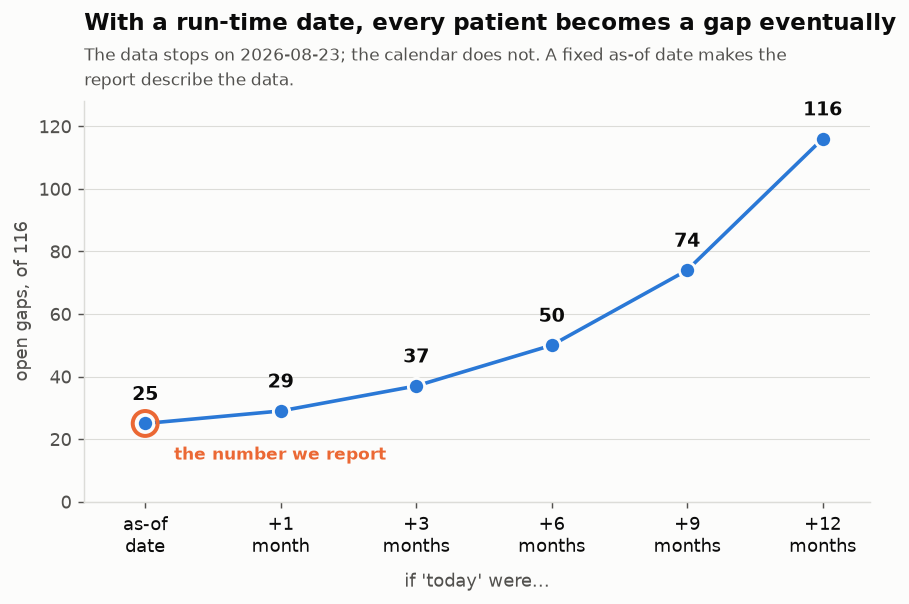

In [22]:
drift = q(f"""
WITH d(label, today) AS (VALUES ('as-of\ndate', DATE '2026-08-23'), ('+1\nmonth', DATE '2026-09-23'),
                                ('+3\nmonths', DATE '2026-11-23'), ('+6\nmonths', DATE '2027-02-23'),
                                ('+9\nmonths', DATE '2027-05-23'), ('+12\nmonths', DATE '2027-08-23'))
SELECT d.label, d.today,
       (SELECT count(*) FROM care_gap_a1c g
        WHERE g.last_a1c_date IS NULL OR date_diff('day', g.last_a1c_date, d.today) > 365) AS gaps
FROM d ORDER BY d.today
""")
fig, ax = plt.subplots(figsize=(7.8, 4.0))
ax.plot(range(len(drift)), drift.gaps, color=BLUE, lw=2, marker="o", ms=9,
        markeredgecolor=SURFACE, markeredgewidth=1.6, zorder=3)
for xi, g in enumerate(drift.gaps):
    ax.annotate(f"{g}", (xi, g), textcoords="offset points", xytext=(0, 13),
                ha="center", fontsize=10.5, fontweight="700", color=INK)
ax.scatter([0], [drift.gaps[0]], s=190, facecolor="none", edgecolor=ORANGE, lw=2.2, zorder=4)
ax.annotate("the number we report", (0, drift.gaps[0]), textcoords="offset points",
            xytext=(16, -20), fontsize=9.5, color=ORANGE, fontweight="600")
ax.set_xticks(range(len(drift)), drift.label, color=INK, fontsize=10)
ax.set_xlabel("if 'today' were...", labelpad=8); ax.set_ylabel("open gaps, of 116")
ax.set_ylim(0, 128); ax.set_xlim(-0.45, 5.35); ax.grid(axis="x", visible=False)
finish(ax, "With a run-time date, every patient becomes a gap eventually",
       "The data stops on 2026-08-23; the calendar does not. A fixed as-of date makes the report describe the data.")
save(fig, "06_asof_drift"); plt.show()

In [23]:
print("saved:")
for f in sorted(os.listdir(IMG)):
    print(f"  docs/img/{f}  {os.path.getsize(IMG + '/' + f)//1024} KB")

saved:
  docs/img/01_cohort_funnel.png  89 KB
  docs/img/02_inner_join.png  63 KB
  docs/img/03_last_a1c_timeline.png  94 KB
  docs/img/04_a1c_floor.png  77 KB
  docs/img/05_gap_by_age.png  72 KB
  docs/img/06_asof_drift.png  92 KB


## Ready to move to `gold.py`

Port the rebuilt table exactly: the extra CTEs, the nine columns, the `priority`
window over open gaps only, and the V4.x assertions. Two questions were dropped
because the data cannot answer them honestly (`lost_to_followup`, phone/email) —
say so on P3 rather than showing a column that is always false.

Also record: **D5** includes "alive on the as-of date" (denominator 116, not 161);
**D6** as written above; and the finding that the 21 never-tested patients are
exactly the complication-only patients with no `44054006` code.

## Release the database

Always the last cell. Frees the file lock so the `.py` scripts can run.

In [24]:
con.close()
print("connection closed - the .py scripts can run now")

connection closed - the .py scripts can run now
